In [1]:
from exoatlas import * 
from exoatlas.visualizations import * 

In [6]:
class GridGallery(Gallery):
    def __init__(self, rows=[Declination, Radius, DepthSNR, TransmissionSNR, EmissionSNR], cols=[RightAscension, Flux, StellarRadius, Radius, StellarBrightness], **kw):
        self.setup_maps(rows, cols, **kw)

    def setup_maps(self, rows=[], cols=[], map_type=BubbleMap, **kw):

        # create the subplots
        map_size = 3
        figsize = (map_size*len(cols), map_size*len(rows))
        self.fi, self.ax = self.create_subplots(nrows=len(rows), ncols=len(cols), figsize=figsize, **kw)

        # attach maps to each ax
        self.maps = {}
        for i, r in enumerate(rows):
            for j, c in enumerate(cols):
                m = map_type(xaxis=c, yaxis=r)
                m.ax = self.ax[i,j]
                self.maps[m.label] = m

    def refine_maps(self):
        """
        Make small changes to Maps, after data are plotted.
        """
        for a in np.atleast_1d(self.ax[:,1:]).flatten():
            a.set_ylabel("")
        for a in np.atleast_1d(self.ax[:-1,:]).flatten():
            a.set_xlabel("")


Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-Exoplanets.txt
Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-Exoplanets.txt
Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-Exoplanets.txt


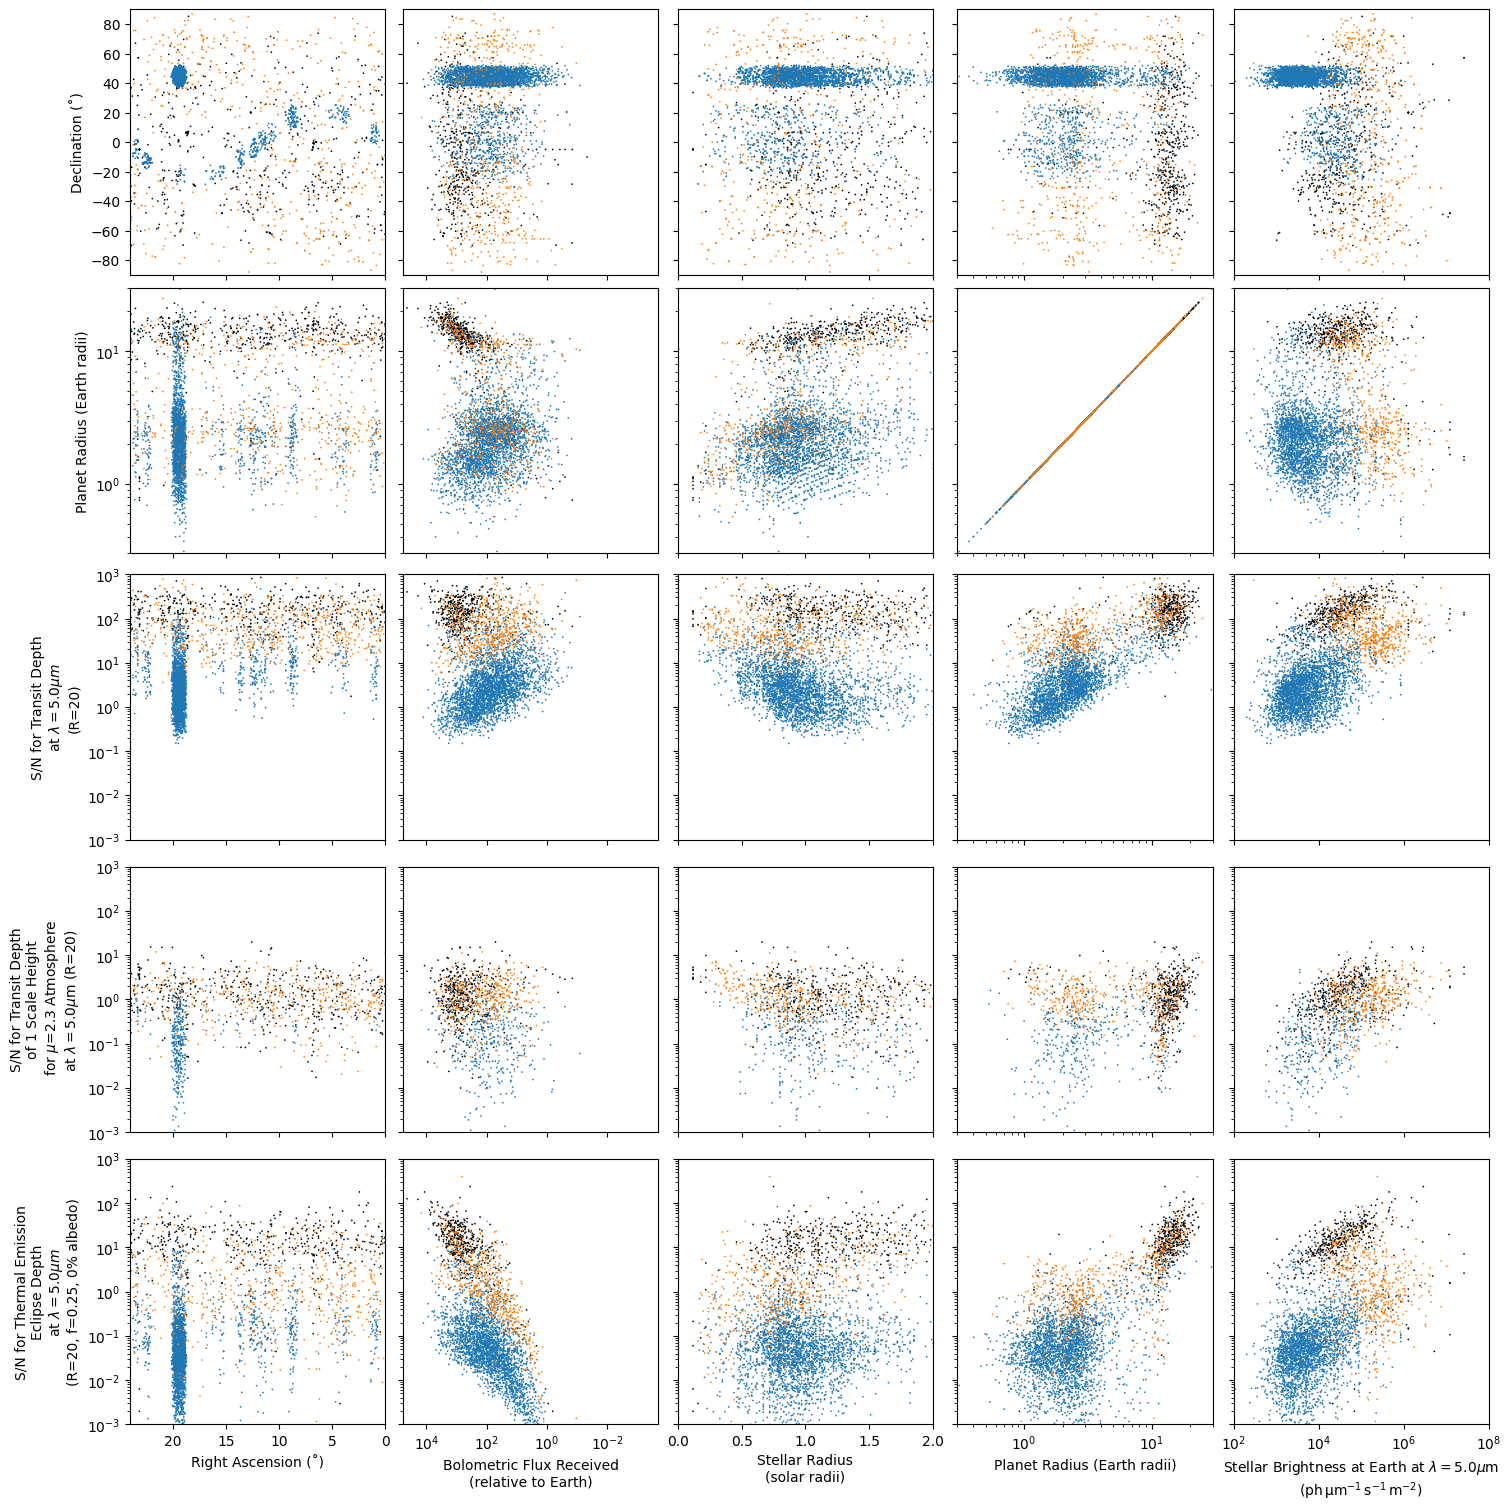

In [7]:
k = Kepler()
t = TESS() 
o = TransitingExoplanets() - k - t
g = GridGallery().build([o, k, t])